In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
file_path = "/content/flood_risk_dataset_india (2).csv"
df = pd.read_csv(file_path)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                10000 non-null  float64
 1   Longitude               10000 non-null  float64
 2   Rainfall (mm)           10000 non-null  float64
 3   Temperature (°C)        10000 non-null  float64
 4   Humidity (%)            10000 non-null  float64
 5   River Discharge (m³/s)  10000 non-null  float64
 6   Water Level (m)         10000 non-null  float64
 7   Elevation (m)           10000 non-null  float64
 8   Historical Floods       10000 non-null  int64  
 9   Flood Occurred          10000 non-null  int64  
dtypes: float64(8), int64(2)
memory usage: 781.4 KB


In [ ]:
if df.isnull().sum().any():
    df.dropna(inplace=True)

In [ ]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (10000, 10)


In [ ]:
# Separate features and target
X = df.drop(columns=['Flood Occurred'])
y = df['Flood Occurred']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# LSTM requires 3D input: [samples, timesteps, features]
# Define a function to reshape data into sequences
def create_sequences(data, labels, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(data) - timesteps):
        X_seq.append(data[i:i+timesteps])
        y_seq.append(labels[i+timesteps])
    return np.array(X_seq), np.array(y_seq)

# Create sequences with 10 timesteps
timesteps = 10
X_lstm_train, y_lstm_train = create_sequences(X_train, y_train.to_numpy(), timesteps)
X_lstm_test, y_lstm_test = create_sequences(X_test, y_test.to_numpy(), timesteps)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [ ]:
sns.set(style='whitegrid', palette='muted')

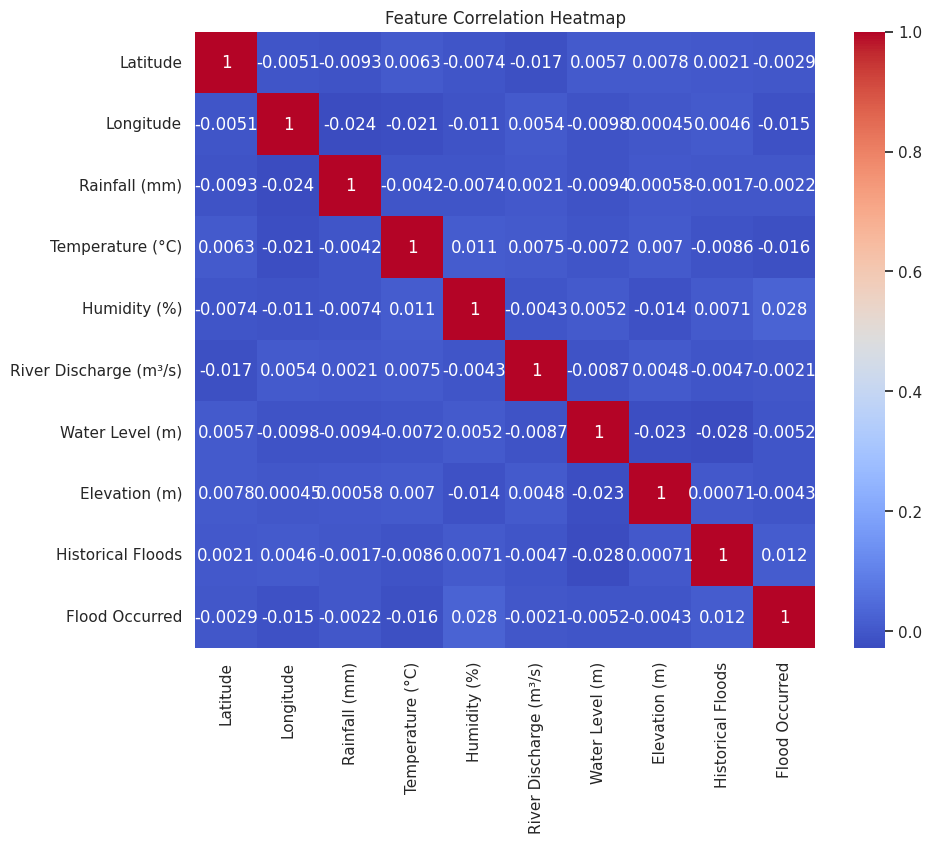

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

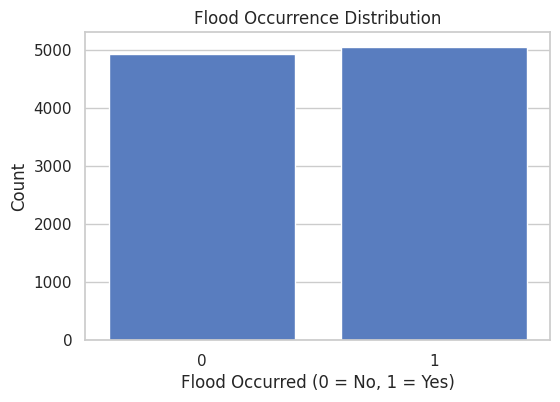

In [ ]:
# 2. Distribution of flood occurrence
plt.figure(figsize=(6, 4))
sns.countplot(x='Flood Occurred', data=df)
plt.title("Flood Occurrence Distribution")
plt.xlabel("Flood Occurred (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

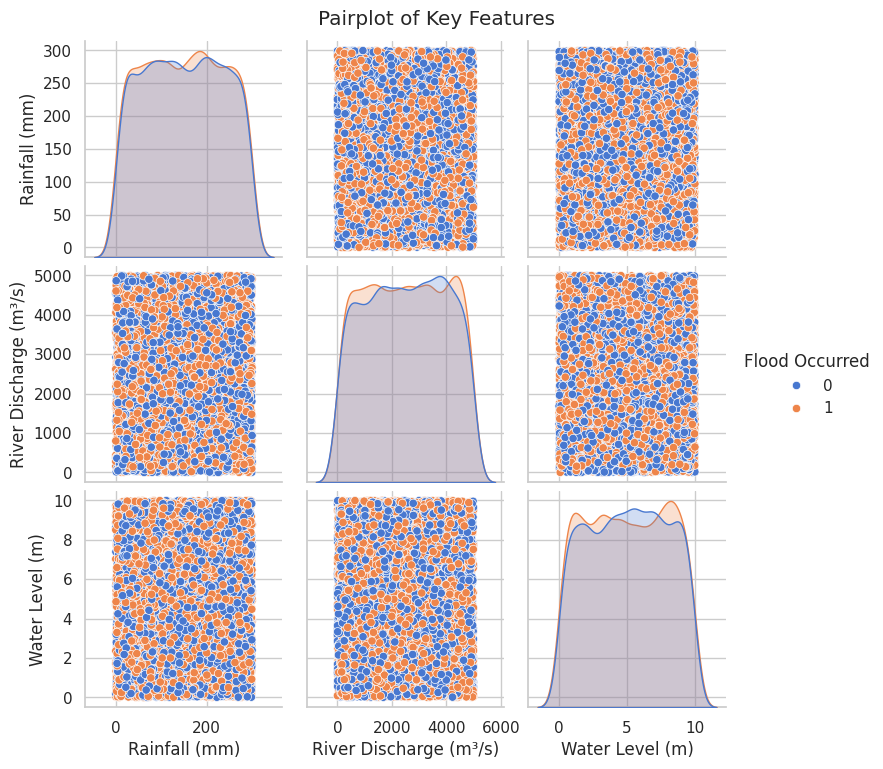

In [ ]:
# 3. Pairplot (subset of features)
subset = df[['Rainfall (mm)', 'River Discharge (m³/s)', 'Water Level (m)', 'Flood Occurred']]
sns.pairplot(subset, hue='Flood Occurred')
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

In [ ]:
# 4. PCA for dimensionality reduction before clustering
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

In [ ]:
# 5. KMeans clustering (2 clusters for simplicity)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(pca_components)

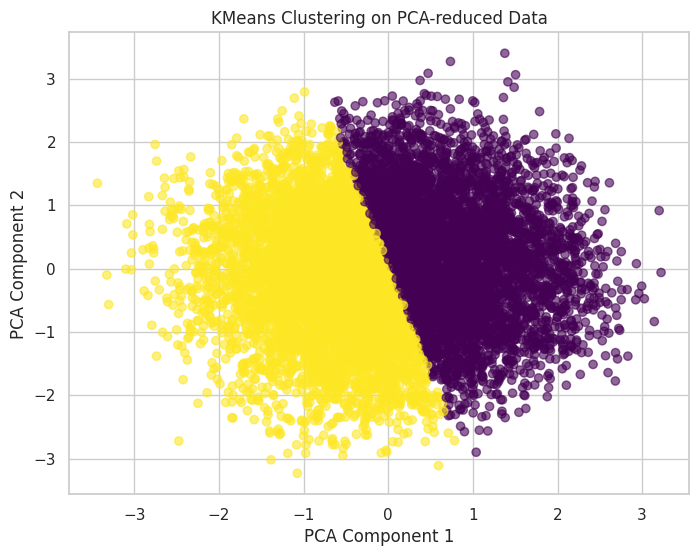

In [ ]:
# 6. Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title("KMeans Clustering on PCA-reduced Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA after scaling
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_pca = pca.fit_transform(X_scaled)

# Train-test split on PCA-reduced data
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# To see how many components were selected
print(f"Original features: {X_scaled.shape[1]}, After PCA: {X_pca.shape[1]}")


Original features: 9, After PCA: 9


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('/content/flood_risk_dataset_india (2).csv')

# Handle missing values (if any)
data.fillna(method='ffill', inplace=True)

# Feature selection: We will use all columns except 'Flood Occurred' for modeling
X = data.drop(columns=['Flood Occurred'])
y = data['Flood Occurred']

# Normalize features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


<ipython-input-22-0d374c87a9fd>:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


LSTM Model for Time-Series Prediction

In [ ]:
def create_lstm_sequences(X, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Create sequences for LSTM
X_lstm, y_lstm = create_lstm_sequences(X_scaled, time_steps=10)
print("X_lstm shape:", X_lstm.shape)  # Should be (samples, 10, 9)
print("y_lstm shape:", y_lstm.shape)  # Should be (samples,)


X_lstm shape: (9990, 10, 9)
y_lstm shape: (9990,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_lstm.shape[1], X_lstm.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=64))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_lstm, y_lstm, epochs=50, batch_size=32, validation_split=0.1)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.2880 - val_loss: 0.2502
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2531 - val_loss: 0.2523
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2535 - val_loss: 0.2505
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.2512 - val_loss: 0.2508
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2509 - val_loss: 0.2519
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2495 - val_loss: 0.2539
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2502 - val_loss: 0.2500
Epoch 8/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2489 - val_loss: 0.2506
Epoch 9/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.2489 - val_loss: 0.2521
Epoch 10/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.2483 - val_loss: 0.2518
Epoch 11/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.2461 - val_loss: 0.2549
Epoch 12/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/ste

XGBoost for Risk Classification

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Train XGBoost model for risk classification
xg_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')
xg_model.fit(X_train, y_train)

# Predict the test set
y_pred = xg_model.predict(X_test)

# Evaluate the model
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))


Accuracy: 0.5075
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.52      0.51       966
           1       0.53      0.49      0.51      1034

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



Simulate Alerts

In [ ]:
# Function to simulate alert system
def simulate_alert(predicted_risk):
    if predicted_risk == 1:
        print("⚠️ ALERT: Risk detected! Situation is RISKY!")
    else:
        print("✅ Situation is SAFE. No risk detected.")

# Example prediction for new data (you can use test data here)
# Suppose we take a random example from the test set
import random

# Pick a random index from the test set
random_index = random.randint(0, X_test.shape[0] - 1)
sample_data = X_test[random_index].reshape(1, -1)  # Reshape to 2D array

# Predict risk using XGBoost model
predicted_risk = xg_model.predict(sample_data)

# Simulate alert based on prediction
simulate_alert(predicted_risk[0])


⚠️ ALERT: Risk detected! Situation is RISKY!


In [ ]:
# Simulate alerts for multiple samples
for i in range(10):  # simulate for 10 samples
    sample_data = X_test[i].reshape(1, -1)
    predicted_risk = xg_model.predict(sample_data)
    print(f"Sample {i+1}:")
    simulate_alert(predicted_risk[0])
    print('-' * 30)


Sample 1:
⚠️ ALERT: Risk detected! Situation is RISKY!
------------------------------
Sample 2:
⚠️ ALERT: Risk detected! Situation is RISKY!
------------------------------
Sample 3:
✅ Situation is SAFE. No risk detected.
------------------------------
Sample 4:
✅ Situation is SAFE. No risk detected.
------------------------------
Sample 5:
⚠️ ALERT: Risk detected! Situation is RISKY!
------------------------------
Sample 6:
⚠️ ALERT: Risk detected! Situation is RISKY!
------------------------------
Sample 7:
✅ Situation is SAFE. No risk detected.
------------------------------
Sample 8:
✅ Situation is SAFE. No risk detected.
------------------------------
Sample 9:
⚠️ ALERT: Risk detected! Situation is RISKY!
------------------------------
Sample 10:
✅ Situation is SAFE. No risk detected.
------------------------------
